# Cyprus Real Estate - Phase A Exploration
## Best Value Property Search Engine

**Date:** March 2, 2026  
**Team:** DataVision  
**Course:** CSE 473/525 Data Science

---

This notebook contains:
1. Mock dataset generation (for development)
2. Exploratory Data Analysis (EDA)
3. Data visualization
4. Initial modeling concepts

## 1. Setup and Imports

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime, timedelta
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Create Mock Dataset

Since web scraping has anti-bot protection, we'll create a realistic mock dataset based on Cyprus real estate market research.

In [2]:
def generate_mock_properties(n=500):
    """
    Generate realistic mock property data for Cyprus
    Based on actual market prices and characteristics
    """
    
    # Define cities and their average price multipliers
    cities = {
        'Limassol': 1.4,   # Most expensive
        'Nicosia': 1.0,    # Baseline
        'Paphos': 1.2,
        'Larnaca': 0.9,
        'Famagusta': 0.8   # Least expensive
    }
    
    # Property types
    property_types = ['apartment', 'house', 'villa', 'studio', 'penthouse', 'maisonette']
    type_multipliers = {
        'studio': 0.5,
        'apartment': 1.0,
        'maisonette': 1.3,
        'house': 1.5,
        'penthouse': 1.8,
        'villa': 2.0
    }
    
    data = []
    
    for i in range(n):
        # Random selections
        city = np.random.choice(list(cities.keys()), p=[0.35, 0.25, 0.2, 0.15, 0.05])
        prop_type = np.random.choice(property_types, p=[0.45, 0.2, 0.1, 0.15, 0.05, 0.05])
        
        # Bedrooms based on type
        if prop_type == 'studio':
            bedrooms = 0
            size_sqm = np.random.randint(25, 50)
        elif prop_type == 'apartment':
            bedrooms = np.random.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
            size_sqm = 40 + bedrooms * 25 + np.random.randint(-10, 20)
        elif prop_type in ['house', 'villa']:
            bedrooms = np.random.choice([3, 4, 5], p=[0.4, 0.4, 0.2])
            size_sqm = 100 + bedrooms * 40 + np.random.randint(-20, 40)
        else:
            bedrooms = np.random.choice([1, 2, 3])
            size_sqm = 50 + bedrooms * 30 + np.random.randint(-15, 25)
        
        # Bathrooms (usually bedrooms or bedrooms + 1)
        bathrooms = max(1, bedrooms if bedrooms > 0 else 1)
        if np.random.random() > 0.6:
            bathrooms += 1
        
        # Base price calculation (€1,800/m² baseline for Nicosia apartment)
        base_price_per_sqm = 1800
        price_per_sqm = base_price_per_sqm * cities[city] * type_multipliers[prop_type]
        
        # Add randomness
        price_per_sqm *= np.random.uniform(0.85, 1.15)
        
        # Calculate total price
        price = int(price_per_sqm * size_sqm)
        
        # Round to nearest 1000
        price = round(price / 1000) * 1000
        
        # Year built
        year_built = np.random.choice(
            [np.random.randint(1980, 2000), 
             np.random.randint(2000, 2015), 
             np.random.randint(2015, 2027)],
            p=[0.3, 0.4, 0.3]
        )
        
        # Features (probability decreases with age)
        age = 2026 - year_built
        has_parking = np.random.random() > (0.3 + age * 0.01)
        has_pool = (prop_type in ['house', 'villa']) and (np.random.random() > 0.6)
        has_garden = (prop_type in ['house', 'villa', 'maisonette']) and (np.random.random() > 0.4)
        
        # Floor (for apartments)
        floor_level = np.random.choice([0, 1, 2, 3, 4, 5]) if prop_type in ['apartment', 'penthouse'] else None
        
        # Energy rating
        energy_ratings = ['A+', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
        if year_built >= 2020:
            energy_rating = np.random.choice(['A+', 'A', 'B'], p=[0.3, 0.5, 0.2])
        elif year_built >= 2010:
            energy_rating = np.random.choice(['A', 'B', 'C', 'D'], p=[0.2, 0.3, 0.3, 0.2])
        else:
            energy_rating = np.random.choice(['C', 'D', 'E', 'F', 'G'], p=[0.2, 0.3, 0.3, 0.1, 0.1])
        
        # Listing date (random within last 90 days)
        days_ago = np.random.randint(0, 90)
        listing_date = (datetime.now() - timedelta(days=days_ago)).strftime('%Y-%m-%d')
        
        # Source (alternating between sources)
        source = 'bazaraki' if i % 2 == 0 else 'spitogatos'
        
        # Create property record
        property_data = {
            'property_id': f'{source[:3].upper()}{i+1:04d}',
            'source': source,
            'title': f'{bedrooms if bedrooms > 0 else "Studio"}-bedroom {prop_type} for sale',
            'price': price,
            'city': city,
            'property_type': prop_type,
            'size_sqm': size_sqm,
            'bedrooms': bedrooms,
            'bathrooms': bathrooms,
            'year_built': int(year_built),
            'floor_level': floor_level,
            'has_parking': bool(has_parking),
            'has_pool': bool(has_pool),
            'has_garden': bool(has_garden),
            'energy_rating': energy_rating,
            'listing_date': listing_date,
            'scraped_date': datetime.now().strftime('%Y-%m-%d')
        }
        
        data.append(property_data)
    
    return pd.DataFrame(data)

# Generate dataset
print("🏗️  Generating mock property dataset...")
df = generate_mock_properties(n=500)

# Add derived features
df['price_per_sqm'] = (df['price'] / df['size_sqm']).round(2)
df['property_age'] = 2026 - df['year_built']

print(f"✅ Generated {len(df)} properties")
print(f"📊 Dataset shape: {df.shape}")

🏗️  Generating mock property dataset...
✅ Generated 500 properties
📊 Dataset shape: (500, 19)


In [3]:
# Preview the data
df.head(10)

,property_id,source,title,price,city,property_type,size_sqm,bedrooms,bathrooms,year_built,floor_level,has_parking,has_pool,has_garden,energy_rating,listing_date,scraped_date,price_per_sqm,property_age
0,BAZ0001,bazaraki,3-bedroom maisonette for sale,277000,Nicosia,maisonette,132,3,3,2006,NaN,False,False,False,E,2026-01-09,2026-03-02,2098.48,20
1,SPI0002,spitogatos,Studio-bedroom studio for sale,25000,Famagusta,studio,30,0,1,2011,NaN,False,False,False,B,2026-01-03,2026-03-02,833.33,15
2,BAZ0003,bazaraki,3-bedroom apartment for sale,233000,Nicosia,apartment,119,3,3,2021,4.0,True,False,False,A,2026-02-10,2026-03-02,1957.98,5
3,SPI0004,spitogatos,3-bedroom apartment for sale,200000,Nicosia,apartment,118,3,4,2003,4.0,False,False,False,F,2026-01-27,2026-03-02,1694.92,23
4,BAZ0005,bazaraki,2-bedroom apartment for sale,120000,Larnaca,apartment,81,2,2,2016,5.0,True,False,False,D,2026-01-14,2026-03-02,1481.48,10
5,SPI0006,spitogatos,4-bedroom house for sale,1133000,Limassol,house,279,4,5,2004,NaN,False,False,False,F,2025-12-28,2026-03-02,4060.93,22
6,BAZ0007,bazaraki,2-bedroom apartment for sale,240000,Limassol,apartment,87,2,2,2017,1.0,True,False,False,B,2026-01-21,2026-03-02,2758.62,9
7,SPI0008,spitogatos,Studio-bedroom studio for sale,25000,Larnaca,studio,36,0,1,2002,NaN,True,False,False,D,2026-01-15,2026-03-02,694.44,24
8,BAZ0009,bazaraki,Studio-bedroom studio for sale,51000,Paphos,studio,47,0,2,1988,NaN,False,False,False,C,2026-01-10,2026-03-02,1085.11,38
9,SPI0010,spitogatos,3-bedroom villa for sale,922000,Nicosia,villa,238,3,3,1983,NaN,False,True,True,E,2026-02-25,2026-03-02,3873.95,43


In [4]:
# Save the mock dataset
df.to_csv('../data/raw/mock_properties.csv', index=False)
df.to_json('../data/raw/mock_properties.json', orient='records', indent=2)
print("💾 Saved mock dataset to data/raw/")

💾 Saved mock dataset to data/raw/


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Statistics

In [5]:
# Dataset info
print("📋 Dataset Information:")
print("="*60)
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_id    500 non-null    object 
 1   source         500 non-null    object 
 2   title          500 non-null    object 
 3   price          500 non-null    int64  
 4   city           500 non-null    object 
 5   property_type  500 non-null    object 
 6   size_sqm       500 non-null    int64  
 7   bedrooms       500 non-null    int64  
 8   bathrooms      500 non-null    int64  
 9   year_built     500 non-null    int64  
 10  floor_level    246 non-null    float64
 11  has_parking    500 non-null    bool   
 12  has_pool       500 non-null    bool   
 13  has_garden     500 non-null    bool   
 14  energy_rating  500 non-null    object 
 15  listing_date   500 non-null    object 
 16  scraped_date   500 non-null    object 
 17  price_per_sqm  500 non-null    

In [6]:
# Statistical summary
df[['price', 'size_sqm', 'bedrooms', 'bathrooms', 'price_per_sqm', 'property_age']].describe()

,price,size_sqm,bedrooms,bathrooms,price_per_sqm,property_age
count,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000
mean,4.150060e+05,140.676000,2.272000,2.832000,2464.880940,19.948000
std,3.851343e+05,90.405206,1.458173,1.357742,1071.206474,12.700863
min,2.000000e+04,25.000000,0.000000,1.000000,611.110000,0.000000
25%,1.430000e+05,78.500000,1.000000,2.000000,1672.552500,8.000000
50%,2.340000e+05,105.500000,2.000000,3.000000,2357.600000,20.000000
75%,6.912500e+05,234.000000,3.000000,4.000000,3071.547500,29.250000
max,1.850000e+06,337.000000,5.000000,6.000000,5694.060000,46.000000


In [7]:
# Missing values check
print("🔍 Missing Values:")
missing = df.isnull().sum()
missing[missing > 0]

🔍 Missing Values:


floor_level    254
dtype: int64

### 3.2 Market Overview

In [8]:
# Properties by city
print("🏙️  Properties by City:")
city_counts = df['city'].value_counts()
print(city_counts)
print(f"\n📊 Percentage:")
print((city_counts / len(df) * 100).round(1))

🏙️  Properties by City:
city
Limassol     189
Nicosia      115
Paphos        87
Larnaca       76
Famagusta     33
Name: count, dtype: int64

📊 Percentage:
city
Limassol     37.8
Nicosia      23.0
Paphos       17.4
Larnaca      15.2
Famagusta     6.6
Name: count, dtype: float64


In [9]:
# Properties by type
print("🏠 Properties by Type:")
type_counts = df['property_type'].value_counts()
print(type_counts)

🏠 Properties by Type:
property_type
apartment     223
house         100
studio         76
villa          56
penthouse      23
maisonette     22
Name: count, dtype: int64


In [10]:
# Average prices by city
print("💰 Average Price by City:")
city_stats = df.groupby('city').agg({
    'price': ['mean', 'median', 'min', 'max'],
    'price_per_sqm': 'mean',
    'property_id': 'count'
}).round(0)
city_stats.columns = ['Avg Price', 'Median Price', 'Min Price', 'Max Price', 'Avg €/m²', 'Count']
city_stats.sort_values('Avg Price', ascending=False)

💰 Average Price by City:


,Avg Price,Median Price,Min Price,Max Price,Avg €/m²,Count
city,,,,,,
Limassol,509661.0,286000.0,30000,1850000,3009.0,189
Paphos,411483.0,228000.0,29000,1354000,2479.0,87
Nicosia,365278.0,200000.0,22000,1157000,2175.0,115
Larnaca,318132.0,177000.0,21000,1064000,1860.0,76
Famagusta,278576.0,139000.0,20000,920000,1714.0,33


## 4. Data Visualization

### 4.1 Price Distributions

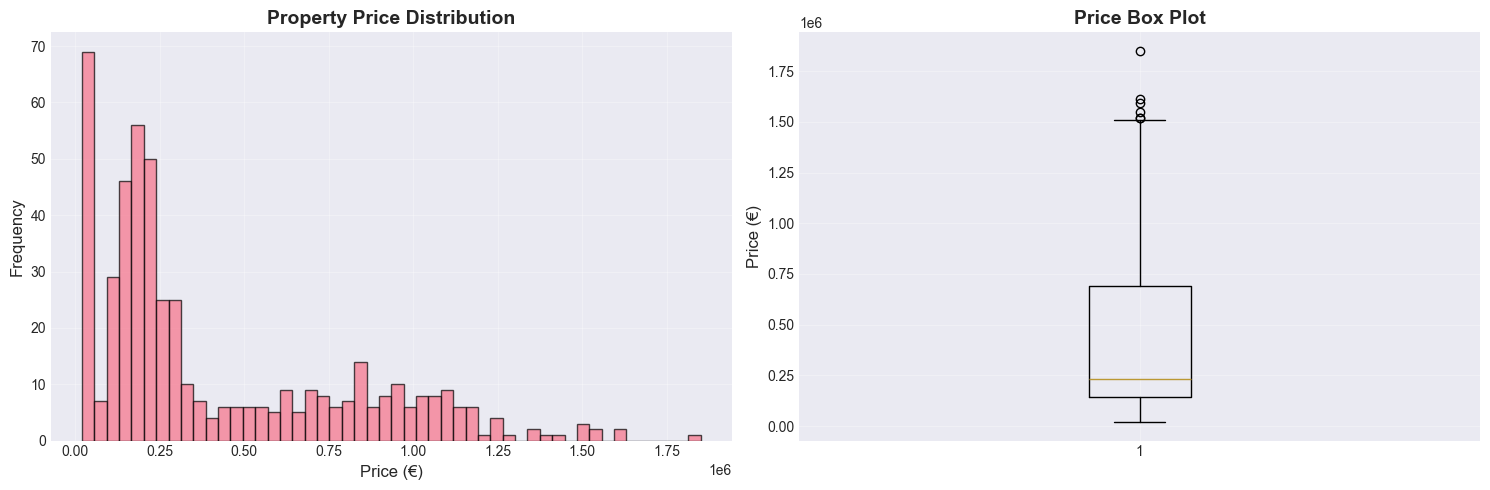

💰 Price Statistics:
   Mean: €415,006
   Median: €234,000
   Std Dev: €385,134


In [11]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (€)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Property Price Distribution', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Price (€)', fontsize=12)
axes[1].set_title('Price Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"💰 Price Statistics:")
print(f"   Mean: €{df['price'].mean():,.0f}")
print(f"   Median: €{df['price'].median():,.0f}")
print(f"   Std Dev: €{df['price'].std():,.0f}")

### 4.2 Price by City

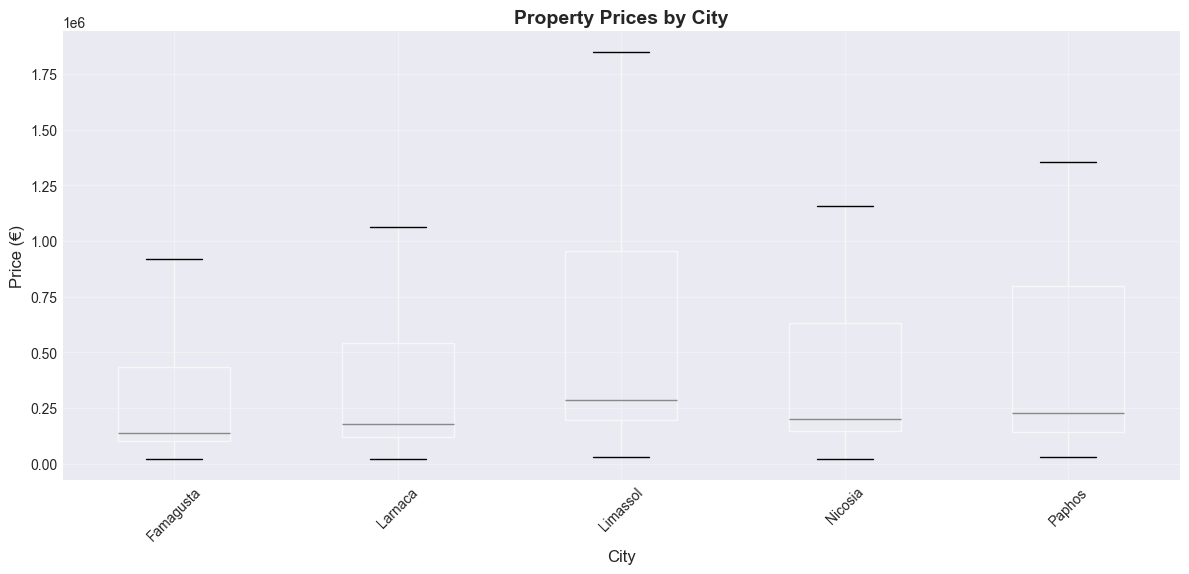

In [12]:
# Box plot: Price by city
plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='city', ax=plt.gca())
plt.suptitle('')
plt.title('Property Prices by City', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Price (€)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

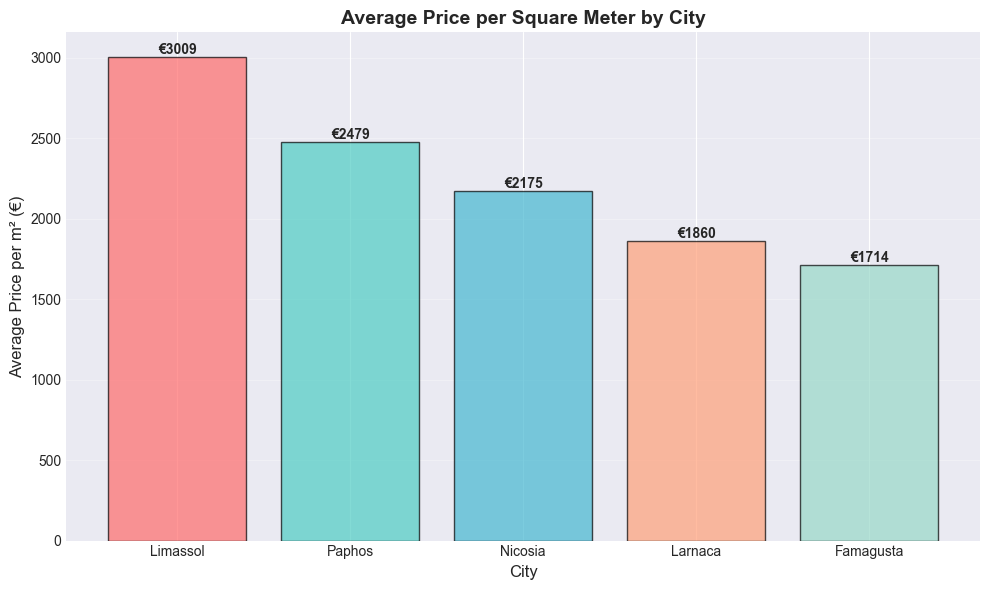

In [13]:
# Bar chart: Average price per m² by city
city_price_sqm = df.groupby('city')['price_per_sqm'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(city_price_sqm.index, city_price_sqm.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
               edgecolor='black', alpha=0.7)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Price per m² (€)', fontsize=12)
plt.title('Average Price per Square Meter by City', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'€{height:.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Property Characteristics

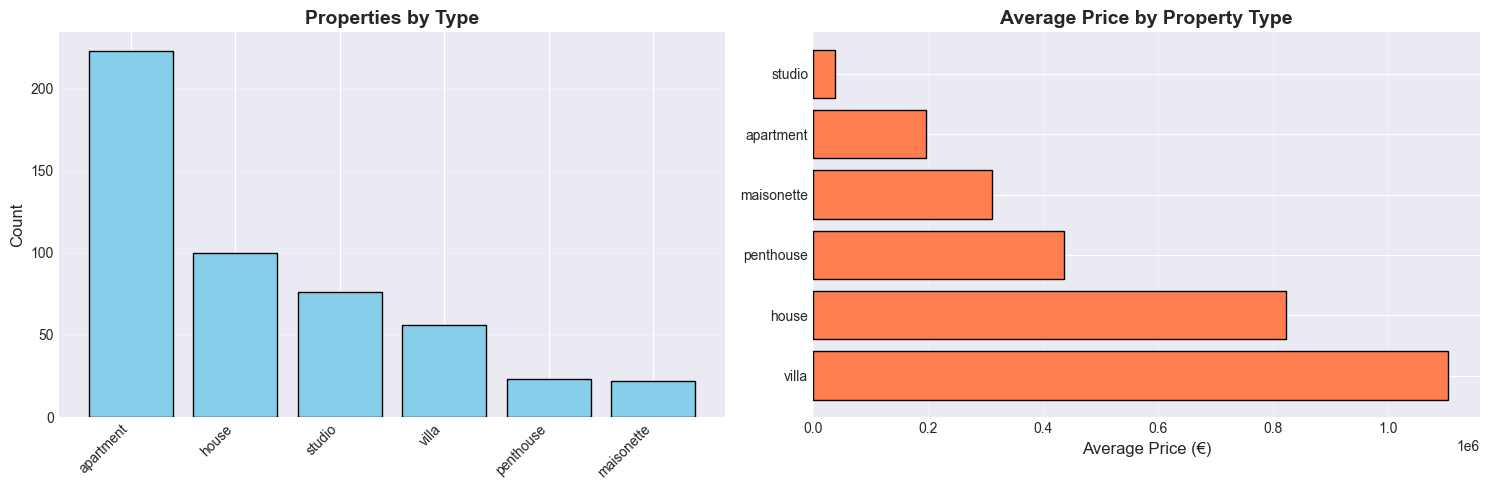

In [14]:
# Property type distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
type_counts = df['property_type'].value_counts()
axes[0].bar(range(len(type_counts)), type_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(type_counts)))
axes[0].set_xticklabels(type_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Properties by Type', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Average price by type
type_price = df.groupby('property_type')['price'].mean().sort_values(ascending=False)
axes[1].barh(range(len(type_price)), type_price.values, color='coral', edgecolor='black')
axes[1].set_yticks(range(len(type_price)))
axes[1].set_yticklabels(type_price.index)
axes[1].set_xlabel('Average Price (€)', fontsize=12)
axes[1].set_title('Average Price by Property Type', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

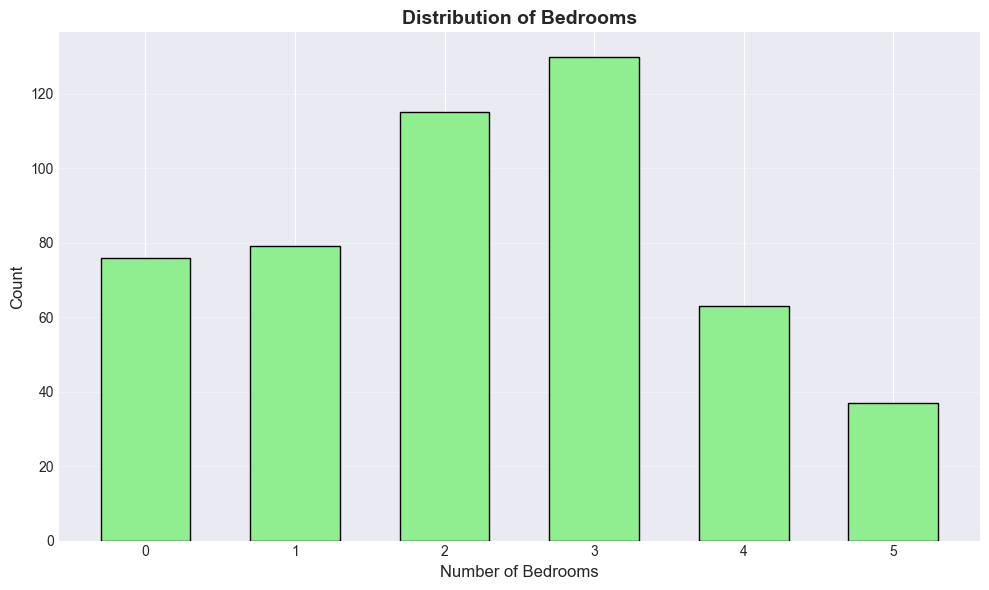

In [15]:
# Bedrooms distribution
plt.figure(figsize=(10, 6))
bedroom_counts = df['bedrooms'].value_counts().sort_index()
plt.bar(bedroom_counts.index, bedroom_counts.values, color='lightgreen', edgecolor='black', width=0.6)
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Bedrooms', fontsize=14, fontweight='bold')
plt.xticks(bedroom_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Price vs Features

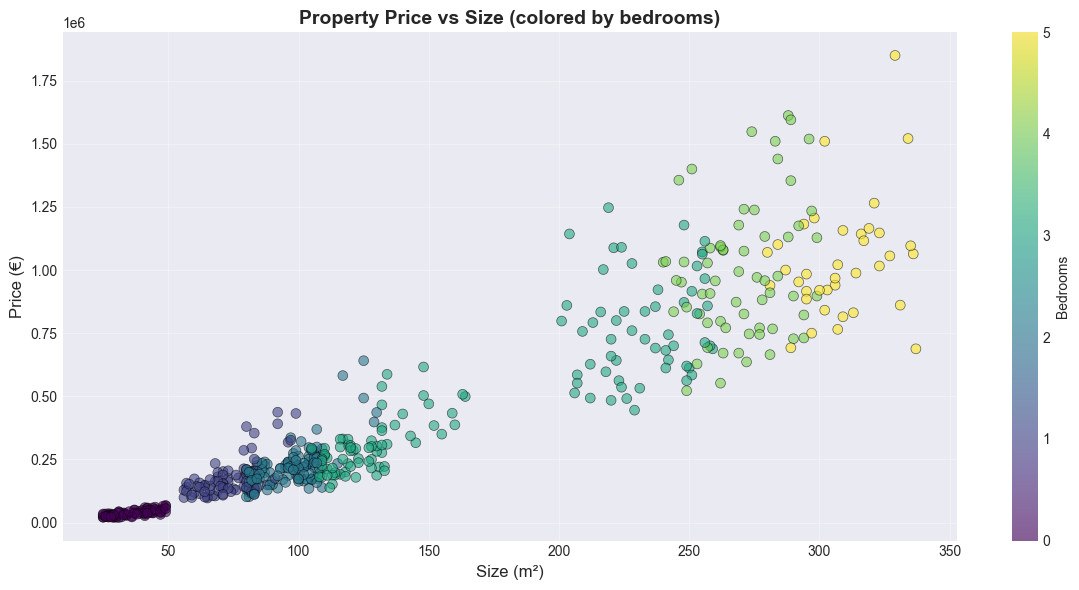

📊 Correlation between Price and Size: 0.929


In [16]:
# Scatter plot: Price vs Size
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df['size_sqm'], df['price'], 
                     c=df['bedrooms'], cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Bedrooms')
plt.xlabel('Size (m²)', fontsize=12)
plt.ylabel('Price (€)', fontsize=12)
plt.title('Property Price vs Size (colored by bedrooms)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
corr = df['price'].corr(df['size_sqm'])
print(f"📊 Correlation between Price and Size: {corr:.3f}")

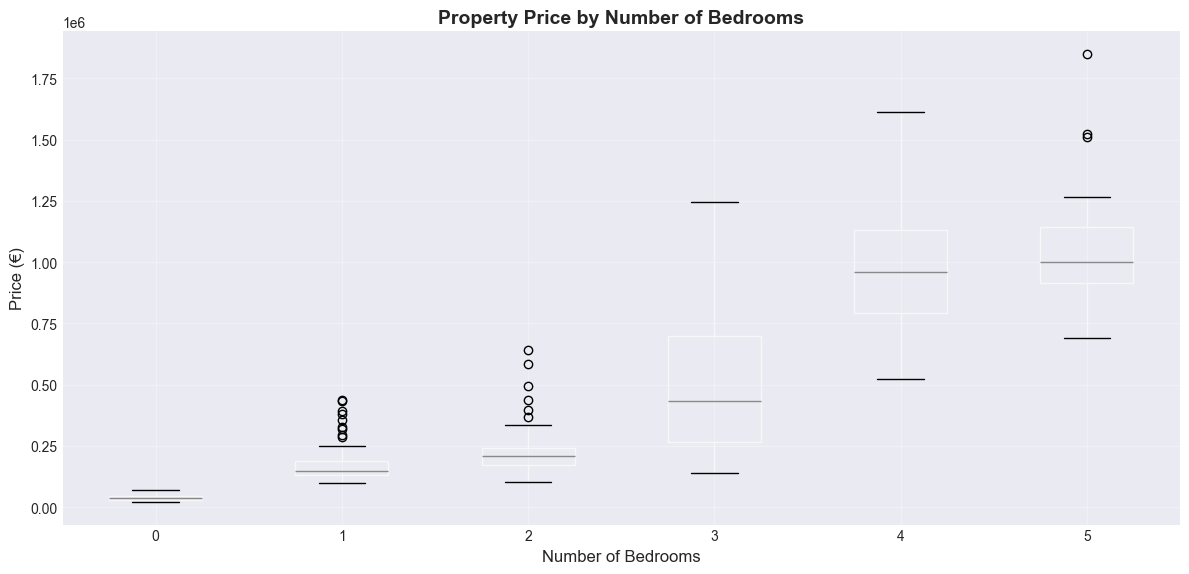

In [17]:
# Price by number of bedrooms
plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='bedrooms', ax=plt.gca())
plt.suptitle('')
plt.title('Property Price by Number of Bedrooms', fontsize=14, fontweight='bold')
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Price (€)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Amenities Impact

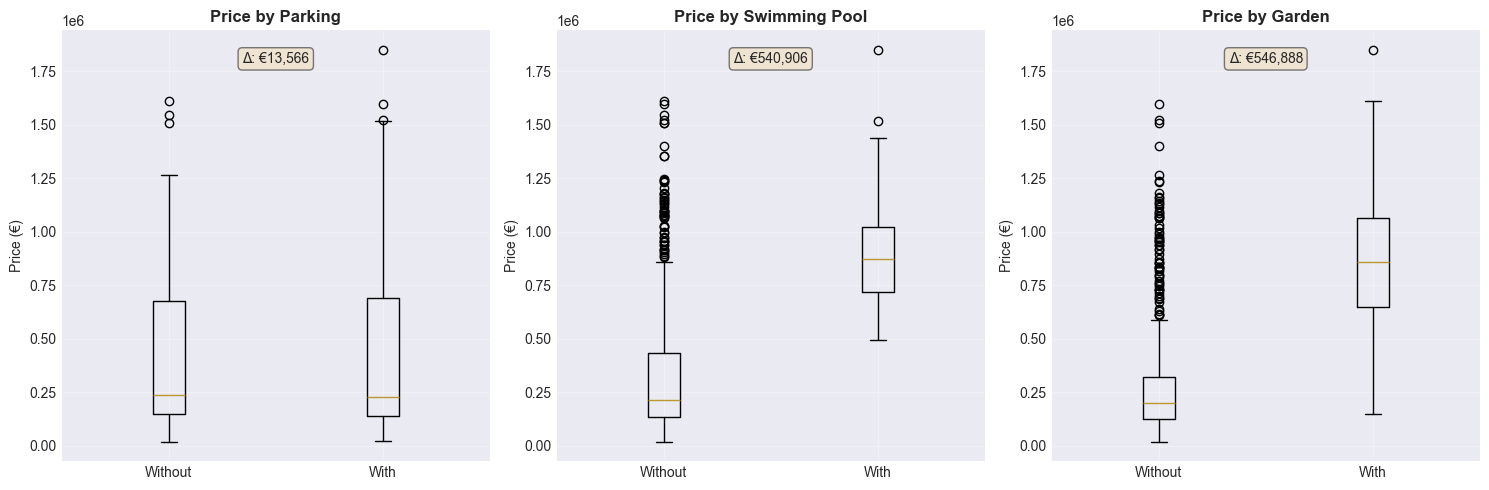

In [18]:
# Compare prices with/without amenities
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

amenities = ['has_parking', 'has_pool', 'has_garden']
titles = ['Parking', 'Swimming Pool', 'Garden']

for i, (amenity, title) in enumerate(zip(amenities, titles)):
    data_with = df[df[amenity] == True]['price']
    data_without = df[df[amenity] == False]['price']
    
    axes[i].boxplot([data_without, data_with], labels=['Without', 'With'])
    axes[i].set_title(f'Price by {title}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Price (€)', fontsize=10)
    axes[i].grid(alpha=0.3)
    
    # Show average difference
    diff = data_with.mean() - data_without.mean()
    axes[i].text(0.5, 0.95, f'Δ: €{diff:,.0f}', 
                transform=axes[i].transAxes, 
                ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### 4.6 Correlation Matrix

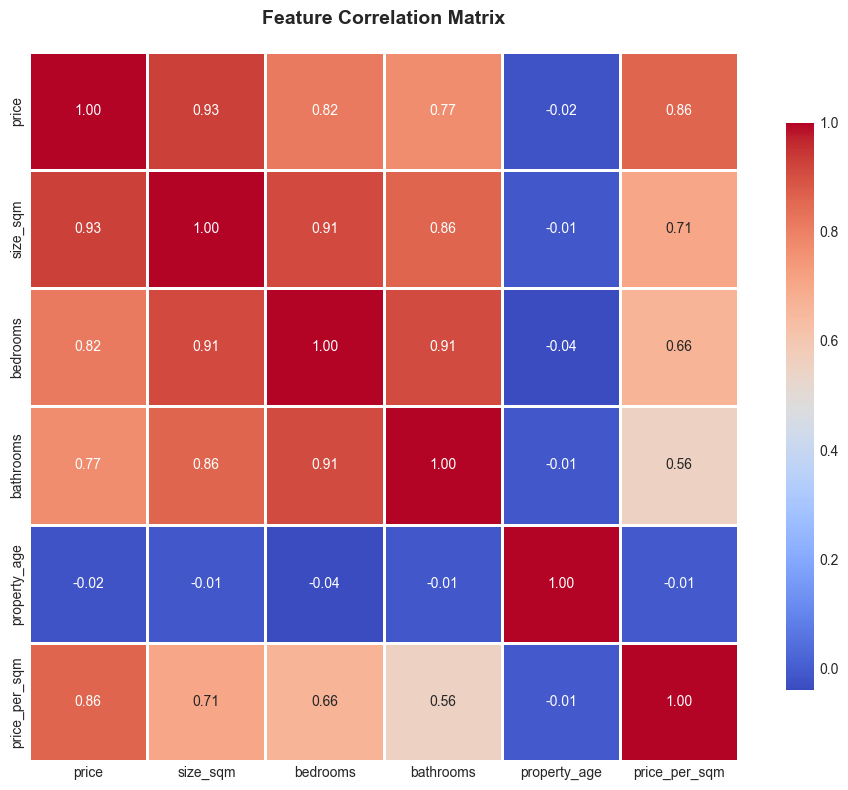

In [19]:
# Correlation matrix for numeric features
numeric_cols = ['price', 'size_sqm', 'bedrooms', 'bathrooms', 'property_age', 'price_per_sqm']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Initial Value Analysis

### 5.1 Identify Pricing Patterns

In [20]:
# Calculate expected price based on simple model (city and size)
city_avg_price_sqm = df.groupby('city')['price_per_sqm'].mean()

def calculate_expected_price(row):
    """Simple price estimation based on city average"""
    avg_price_sqm = city_avg_price_sqm[row['city']]
    return avg_price_sqm * row['size_sqm']

df['expected_price'] = df.apply(calculate_expected_price, axis=1)
df['price_difference'] = df['price'] - df['expected_price']
df['value_score'] = (df['expected_price'] / df['price']).round(3)

print("✅ Value scores calculated")

✅ Value scores calculated


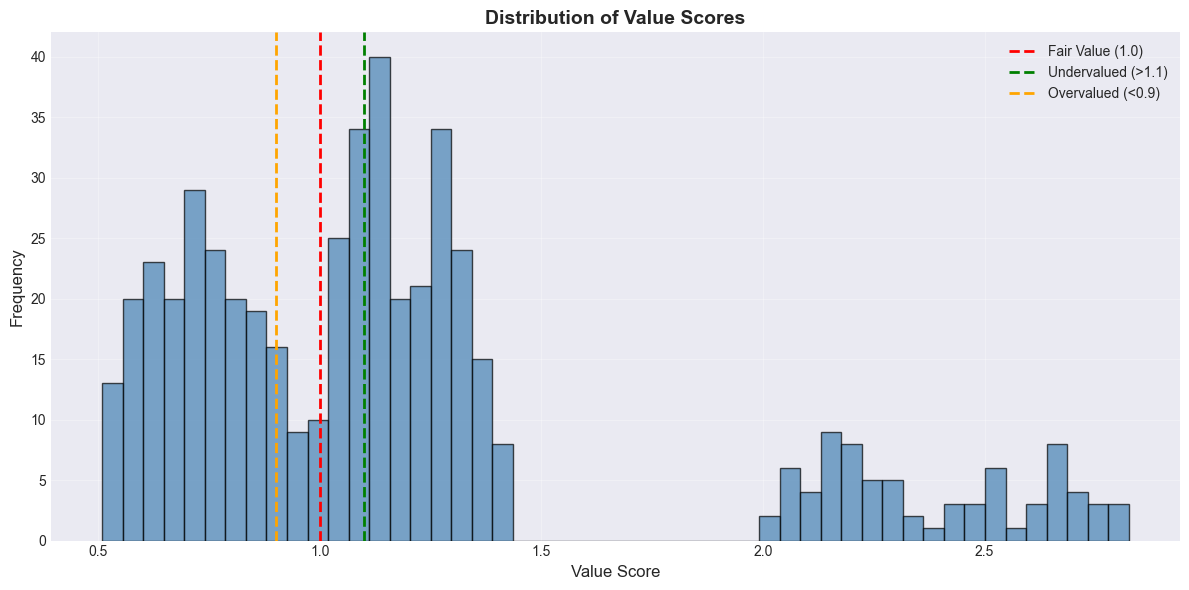

In [21]:
# Value score distribution
plt.figure(figsize=(12, 6))
plt.hist(df['value_score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Fair Value (1.0)')
plt.axvline(1.1, color='green', linestyle='--', linewidth=2, label='Undervalued (>1.1)')
plt.axvline(0.9, color='orange', linestyle='--', linewidth=2, label='Overvalued (<0.9)')
plt.xlabel('Value Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Value Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Find Best Value Properties

In [22]:
# Top 20 undervalued properties (Value Score > 1.1)
undervalued = df[df['value_score'] > 1.1].sort_values('value_score', ascending=False)

print(f"🎯 Found {len(undervalued)} potentially undervalued properties (Value Score > 1.1)")
print("\n📋 Top 20 Best Value Properties:")
print("="*80)

display_cols = ['title', 'city', 'price', 'size_sqm', 'bedrooms', 'value_score']
undervalued[display_cols].head(20)

🎯 Found 247 potentially undervalued properties (Value Score > 1.1)

📋 Top 20 Best Value Properties:


,title,city,price,size_sqm,bedrooms,value_score
157,Studio-bedroom studio for sale,Limassol,49000,46,0,2.825
246,Studio-bedroom studio for sale,Limassol,30000,28,0,2.808
441,Studio-bedroom studio for sale,Famagusta,22000,36,0,2.805
314,Studio-bedroom studio for sale,Limassol,52000,48,0,2.777
107,Studio-bedroom studio for sale,Limassol,36000,33,0,2.758
235,Studio-bedroom studio for sale,Limassol,45000,41,0,2.741
249,Studio-bedroom studio for sale,Larnaca,32000,47,0,2.732
312,Studio-bedroom studio for sale,Limassol,32000,29,0,2.727
116,Studio-bedroom studio for sale,Nicosia,24000,30,0,2.719
17,Studio-bedroom studio for sale,Larnaca,22000,32,0,2.706


In [23]:
# Statistics on undervalued properties
print("📊 Undervalued Properties by City:")
print(undervalued['city'].value_counts())

print("\n📊 Undervalued Properties by Type:")
print(undervalued['property_type'].value_counts())

📊 Undervalued Properties by City:
city
Limassol     95
Nicosia      59
Larnaca      40
Paphos       36
Famagusta    17
Name: count, dtype: int64

📊 Undervalued Properties by Type:
property_type
apartment    171
studio        76
Name: count, dtype: int64


### 5.3 Visualize Value Distribution

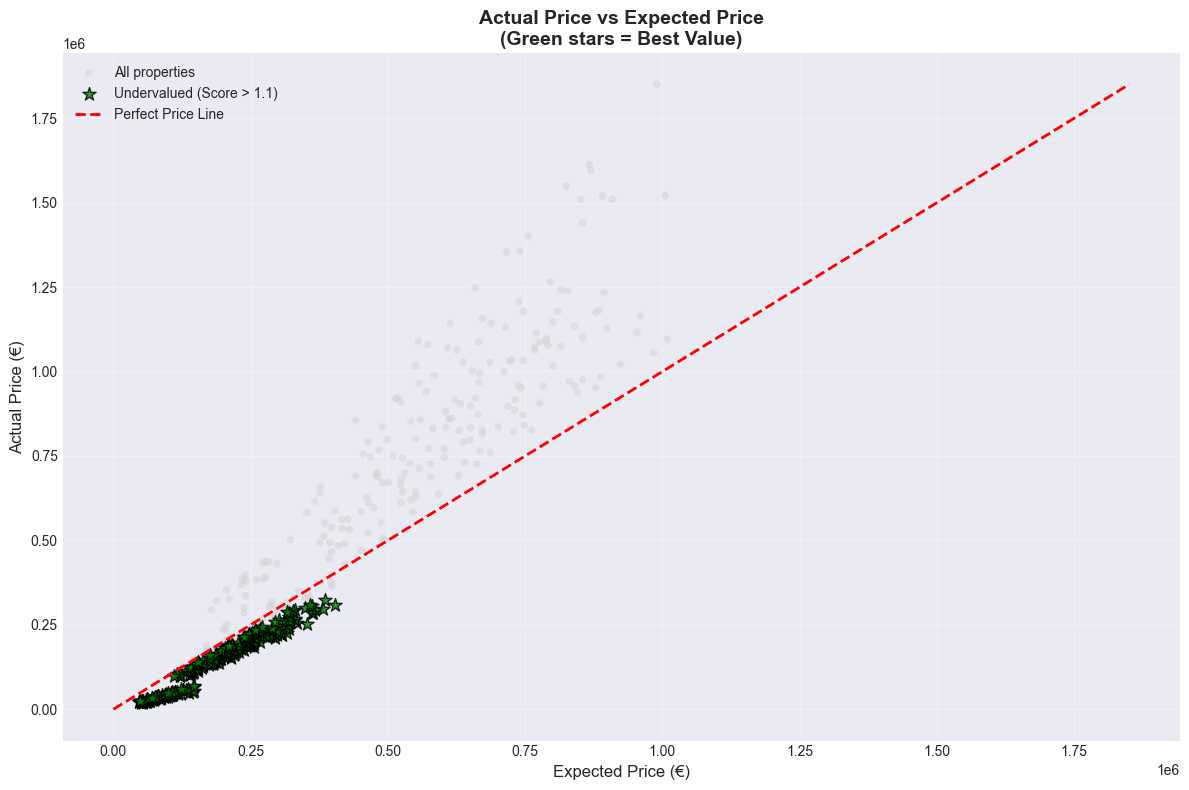

In [24]:
# Scatter plot: Price vs Expected Price
plt.figure(figsize=(12, 8))

# All properties
plt.scatter(df['expected_price'], df['price'], 
           alpha=0.5, s=30, c='lightgray', edgecolors='none', label='All properties')

# Undervalued properties
plt.scatter(undervalued['expected_price'], undervalued['price'], 
           alpha=0.8, s=100, c='green', edgecolors='black', linewidth=1, 
           label='Undervalued (Score > 1.1)', marker='*')

# Perfect price line
max_price = df['price'].max()
plt.plot([0, max_price], [0, max_price], 'r--', linewidth=2, label='Perfect Price Line')

plt.xlabel('Expected Price (€)', fontsize=12)
plt.ylabel('Actual Price (€)', fontsize=12)
plt.title('Actual Price vs Expected Price\n(Green stars = Best Value)', 
         fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Key Insights & Findings

In [25]:
print("="*80)
print("📊 KEY FINDINGS - CYPRUS REAL ESTATE MARKET")
print("="*80)

print(f"\n1️⃣  MARKET OVERVIEW")
print(f"   • Total properties analyzed: {len(df)}")
print(f"   • Average property price: €{df['price'].mean():,.0f}")
print(f"   • Median property price: €{df['price'].median():,.0f}")
print(f"   • Average price per m²: €{df['price_per_sqm'].mean():,.0f}")

print(f"\n2️⃣  PRICE BY CITY (Most to Least Expensive)")
city_ranking = df.groupby('city')['price_per_sqm'].mean().sort_values(ascending=False)
for i, (city, price) in enumerate(city_ranking.items(), 1):
    print(f"   {i}. {city}: €{price:,.0f}/m²")

print(f"\n3️⃣  MOST COMMON PROPERTY TYPES")
for prop_type, count in df['property_type'].value_counts().head(3).items():
    pct = (count / len(df)) * 100
    print(f"   • {prop_type.title()}: {count} ({pct:.1f}%)")

print(f"\n4️⃣  VALUE OPPORTUNITIES")
print(f"   • Undervalued properties found: {len(undervalued)} ({len(undervalued)/len(df)*100:.1f}%)")
print(f"   • Average savings on undervalued: €{undervalued['price_difference'].abs().mean():,.0f}")
print(f"   • Best value score: {undervalued['value_score'].max():.2f}")

print(f"\n5️⃣  AMENITIES IMPACT ON PRICE")
for amenity, name in [('has_pool', 'Pool'), ('has_parking', 'Parking'), ('has_garden', 'Garden')]:
    with_amenity = df[df[amenity] == True]['price'].mean()
    without_amenity = df[df[amenity] == False]['price'].mean()
    diff = with_amenity - without_amenity
    print(f"   • {name}: +€{diff:,.0f} premium")

print(f"\n6️⃣  STRONGEST PRICE CORRELATIONS")
price_corr = df[numeric_cols].corr()['price'].sort_values(ascending=False)[1:4]
for feature, corr in price_corr.items():
    print(f"   • {feature}: {corr:.3f}")

print("\n" + "="*80)

📊 KEY FINDINGS - CYPRUS REAL ESTATE MARKET

1️⃣  MARKET OVERVIEW
   • Total properties analyzed: 500
   • Average property price: €415,006
   • Median property price: €234,000
   • Average price per m²: €2,465

2️⃣  PRICE BY CITY (Most to Least Expensive)
   1. Limassol: €3,009/m²
   2. Paphos: €2,479/m²
   3. Nicosia: €2,175/m²
   4. Larnaca: €1,860/m²
   5. Famagusta: €1,714/m²

3️⃣  MOST COMMON PROPERTY TYPES
   • Apartment: 223 (44.6%)
   • House: 100 (20.0%)
   • Studio: 76 (15.2%)

4️⃣  VALUE OPPORTUNITIES
   • Undervalued properties found: 247 (49.4%)
   • Average savings on undervalued: €45,814
   • Best value score: 2.83

5️⃣  AMENITIES IMPACT ON PRICE
   • Pool: +€540,906 premium
   • Parking: +€13,566 premium
   • Garden: +€546,888 premium

6️⃣  STRONGEST PRICE CORRELATIONS
   • size_sqm: 0.929
   • price_per_sqm: 0.861
   • bedrooms: 0.817



## 7. Next Steps for Phase A

### Completed:
- ✅ Mock dataset generation
- ✅ Exploratory data analysis
- ✅ Data visualization
- ✅ Initial value scoring model

### To Do:
1. **Web Scraping**: Fix scrapers to collect real data from Bazaraki & Spitogatos
2. **Database**: Set up PostgreSQL and populate with data
3. **Advanced Modeling**: Implement ML models for price prediction
4. **Report**: Finalize Phase A report with findings and visualizations
5. **Presentation**: Create slides for Phase A presentation (March 31)

### For Phase B:
- Build interactive Streamlit dashboard
- Implement real-time data updates
- Add model monitoring and drift detection
- User authentication and saved searches

## 8. Export Results for Report

In [26]:
# Save top undervalued properties
undervalued[display_cols].head(20).to_csv('../data/processed/top_value_properties.csv', index=False)

# Save summary statistics
summary_stats = {
    'total_properties': len(df),
    'avg_price': df['price'].mean(),
    'median_price': df['price'].median(),
    'avg_price_per_sqm': df['price_per_sqm'].mean(),
    'undervalued_count': len(undervalued),
    'undervalued_percentage': len(undervalued) / len(df) * 100
}

with open('../data/processed/market_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("✅ Results exported to data/processed/")
print("   • top_value_properties.csv")
print("   • market_summary.json")

✅ Results exported to data/processed/
   • top_value_properties.csv
   • market_summary.json
